In [2]:
import pandas as pd
import numpy as np

In [3]:
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score 
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer 

In [4]:
df = pd.read_csv('Titanic-Dataset.csv', usecols=['Age','Fare','Survived'])  

In [5]:
df.head()                    

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [7]:
# replace all missing values of 'Age' with its mean value 

df['Age'].fillna(df['Age'].mean(), inplace=True)  

C:\Users\munna\AppData\Local\Temp\ipykernel_1724\1403923996.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [8]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [9]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [10]:
X = df.iloc[:,1:3]
y = df.iloc[:,0] 

In [11]:
# now, perform train_test_split operation

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42) 

In [12]:
X_train.shape  

(712, 2)

In [13]:
y_train.shape

(712,)

C:\Users\munna\AppData\Local\Temp\ipykernel_1724\2955928759.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


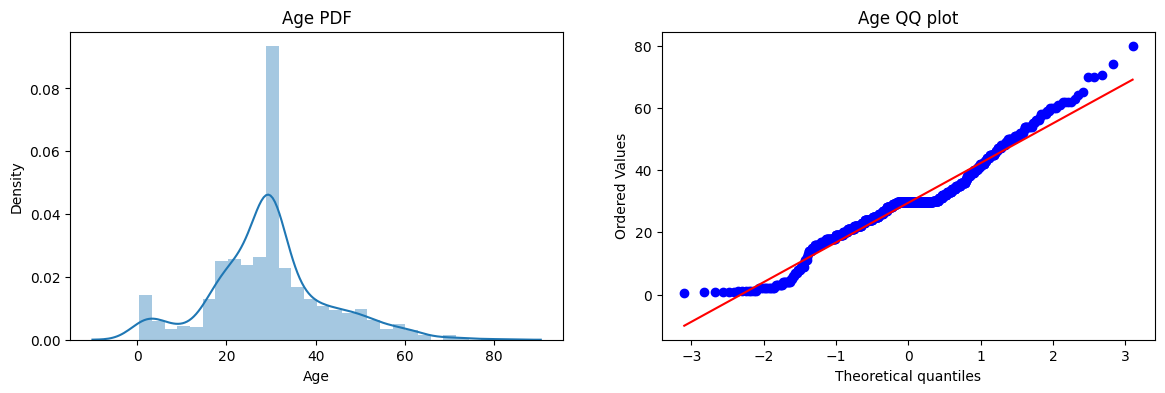

In [14]:
# Now, analyze the diference between the PDA(normal distribution) and QQ plot 

# for PDA graph of Age

plt.figure(figsize=(14,4)) 
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

# for QQ plotting of Age

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ plot')

plt.show()

C:\Users\munna\AppData\Local\Temp\ipykernel_1724\1205606983.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


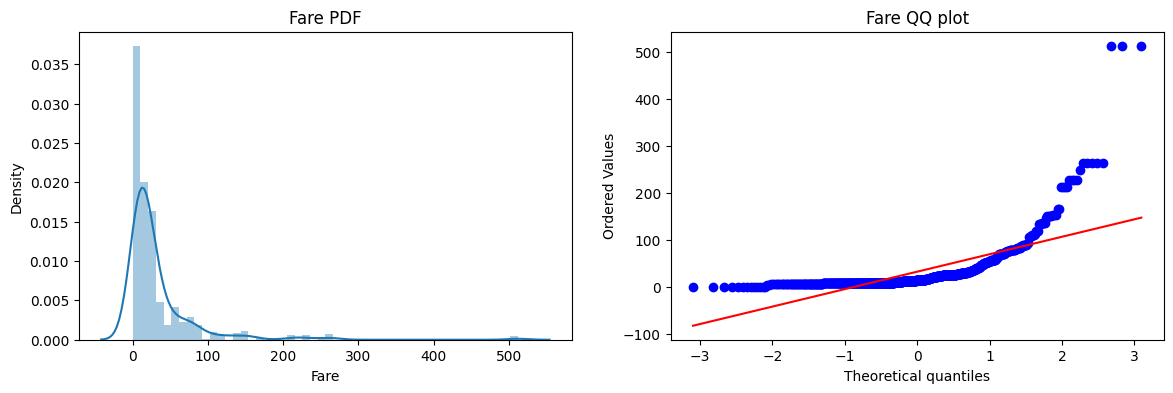

In [15]:
# Now, analyze the diference between the PDA(normal distribution) and QQ plot 

# for PDA graph of Fare

plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Fare PDF')

# for QQ plotting of Fare

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ plot')

plt.show()

In [16]:
# creating two objects

clf = LogisticRegression()
clf2 = DecisionTreeClassifier() 

In [17]:
# train the model and find its accuracy using both these algorithms

clf.fit(X_train,y_train)     
clf2.fit(X_train,y_train)       

y_pred = clf.predict(X_test)    # predictions made by the 1st algorithm (clf)
y_pred1 = clf2.predict(X_test)  # predictions made by the 2nd algorithm (clf2)   

print("Accuracy LR",accuracy_score(y_test,y_pred))  # compares predictions to the actual answers(y_test) of clf
print("Accuracy DT",accuracy_score(y_test,y_pred1)) # compares predictions to the actual answers (y_test) of clf2 

Accuracy LR 0.6480446927374302
Accuracy DT 0.6815642458100558


In [18]:
# Now, Apply "log transformer" on both('Age' & 'Fare') to check, is there any improvement or not

trf = FunctionTransformer(func=np.log1p)    

In [19]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test) 

In [20]:
# doing same thing again, check accuracy by making two clf objectslO

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)
 
print("Accuracy LR", accuracy_score(y_test,y_pred)) 
print("Accuracy DT", accuracy_score(y_test,y_pred1)) 

Accuracy LR 0.6815642458100558
Accuracy DT 0.664804469273743


In [21]:
X_transformed = trf.fit_transform(X)
    
clf = LogisticRegression()
clf2 = DecisionTreeClassifier() 
    
print("Accuracy LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("Accuracy DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))
     

Accuracy LR 0.678027465667915
Accuracy DT 0.6577153558052433


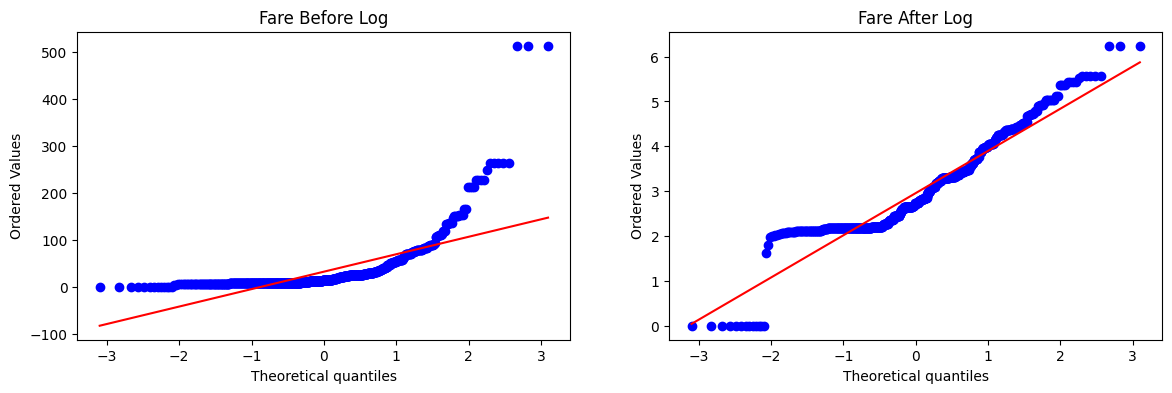

In [22]:
plt.figure(figsize=(14,4))
    
plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

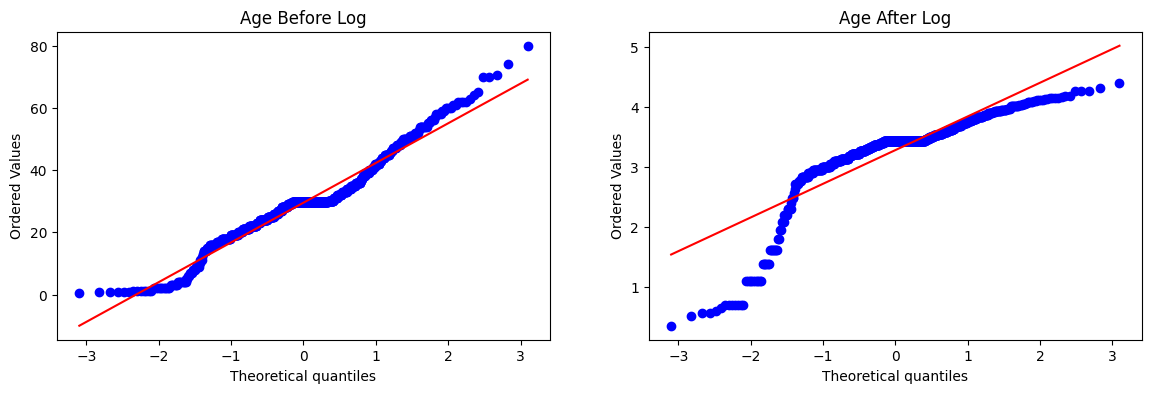

In [23]:
plt.figure(figsize=(14,4))
    
plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')
    
plt.show()

In [24]:
 trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')
    
X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)  

In [25]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()
    
clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6759776536312849


In [26]:
X_transformed2 = trf2.fit_transform(X)
    
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()
    
print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))
   

LR 0.6712609238451936
DT 0.6565792759051186


In [29]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()    
    

In [ ]:
# you can apply any transformation on it and check accuracy according to that

Accuracy 0.6589013732833957


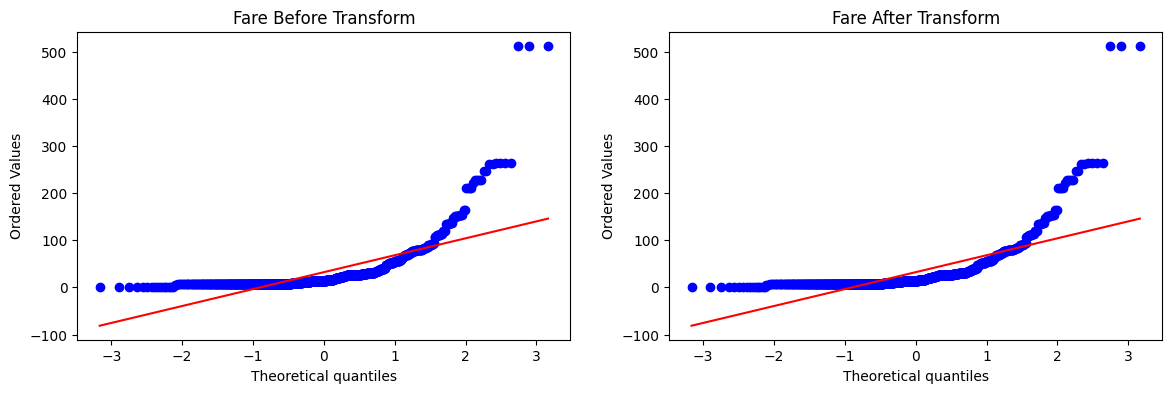

In [46]:
apply_transform(lambda x : x)

Accuracy 0.6431335830212235


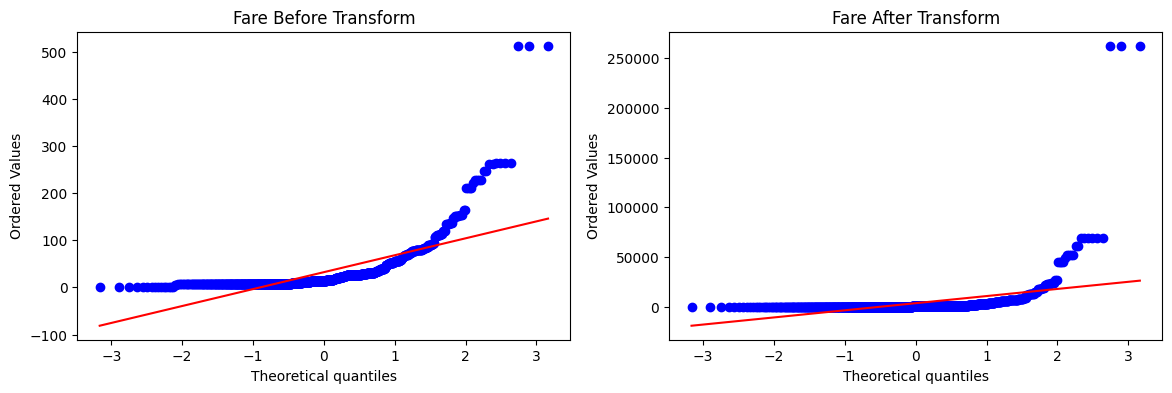

In [30]:
apply_transform(lambda x : x**2)

Accuracy 0.6262796504369538


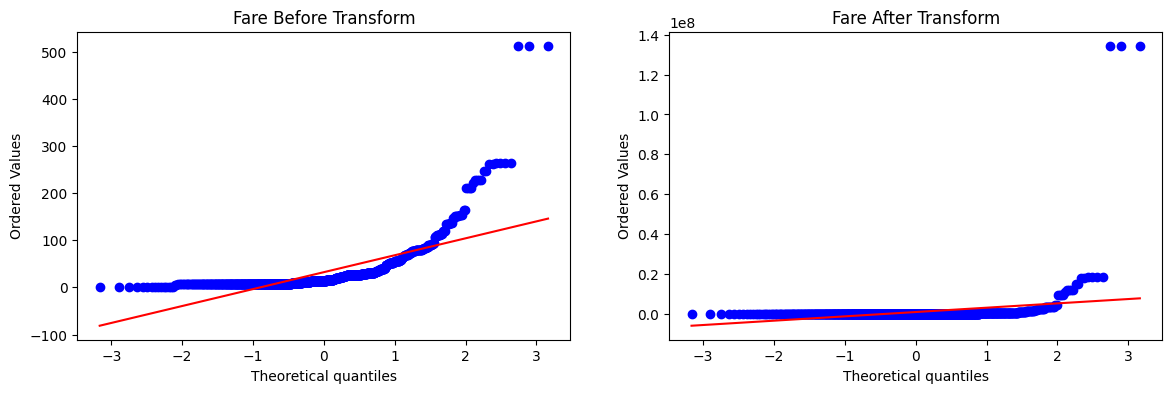

In [33]:
apply_transform(lambda x : x**3)

Accuracy 0.6589013732833957


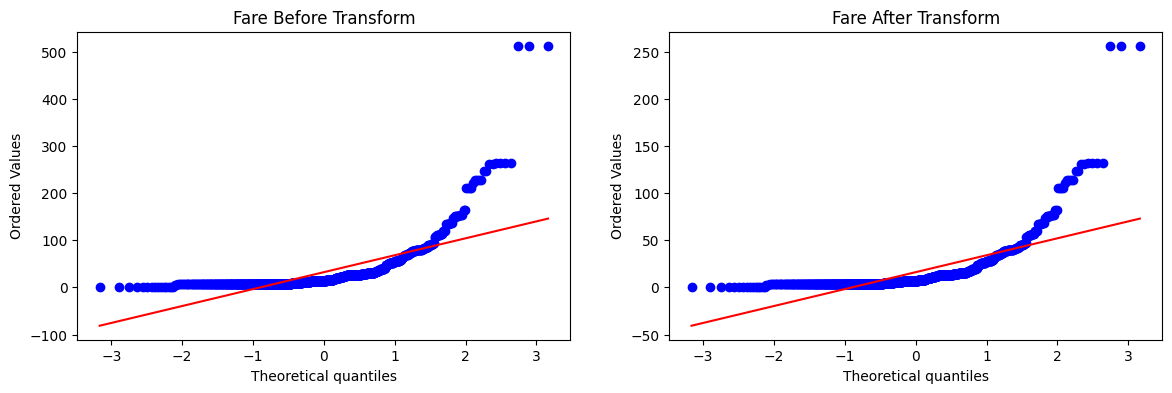

In [32]:
apply_transform(lambda x : x**1/2)

Accuracy 0.61729088639201


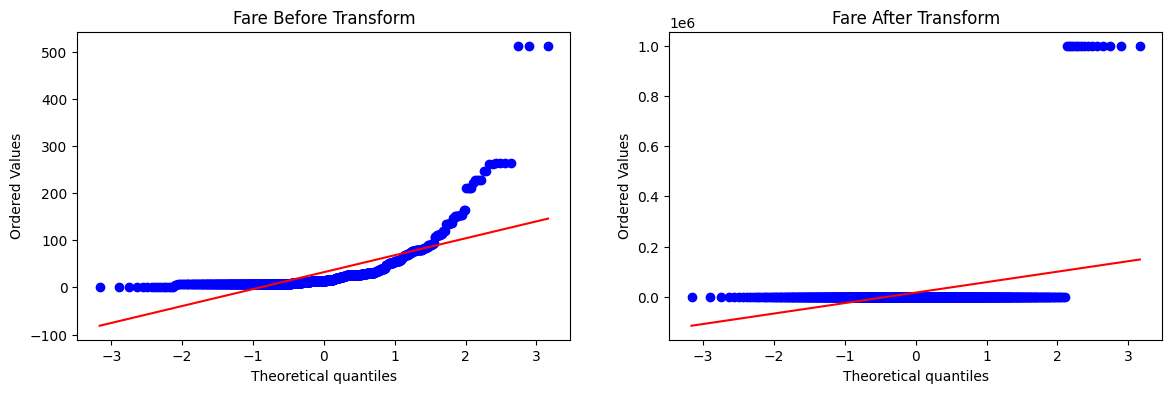

In [35]:
apply_transform(lambda x: 1 / (x+0.000001))

Accuracy 0.6589013732833957


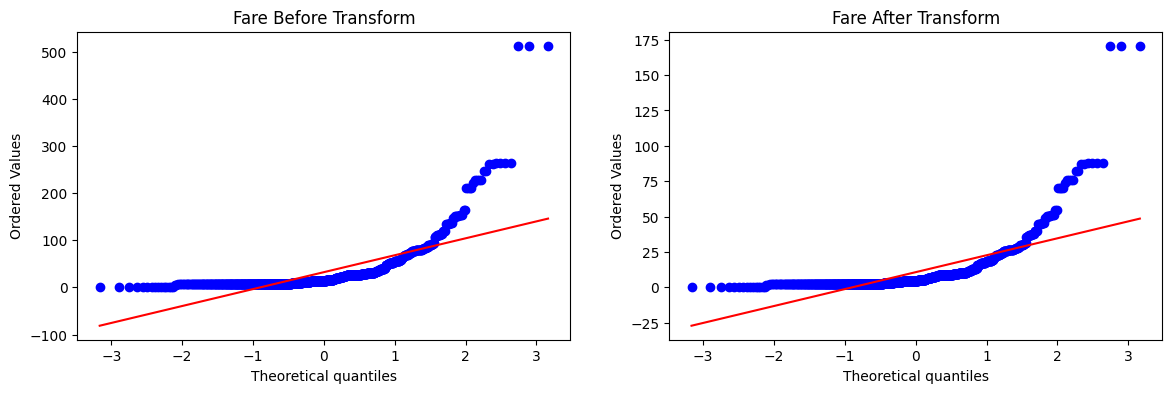

In [36]:
apply_transform(lambda x : x**1/3)

Accuracy 0.61729088639201


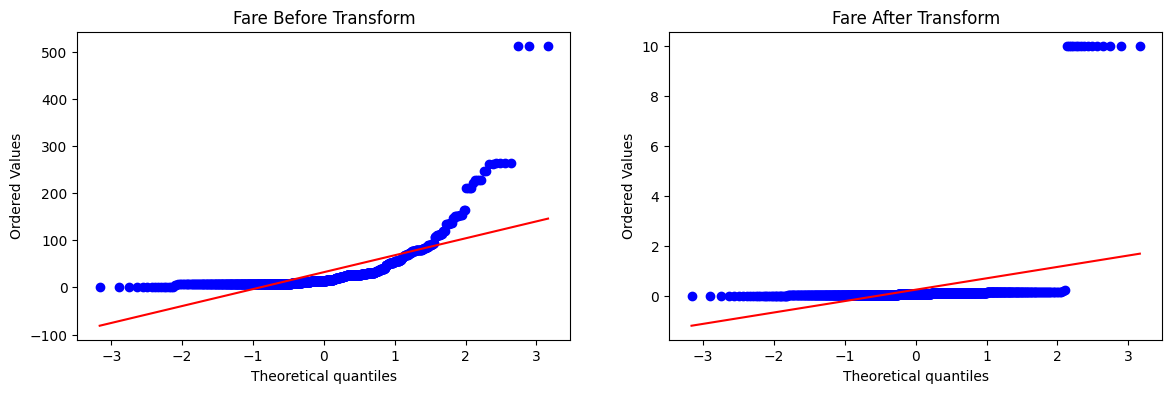

In [38]:
apply_transform(lambda x : 1/(x+0.1))

Accuracy 0.6150561797752809


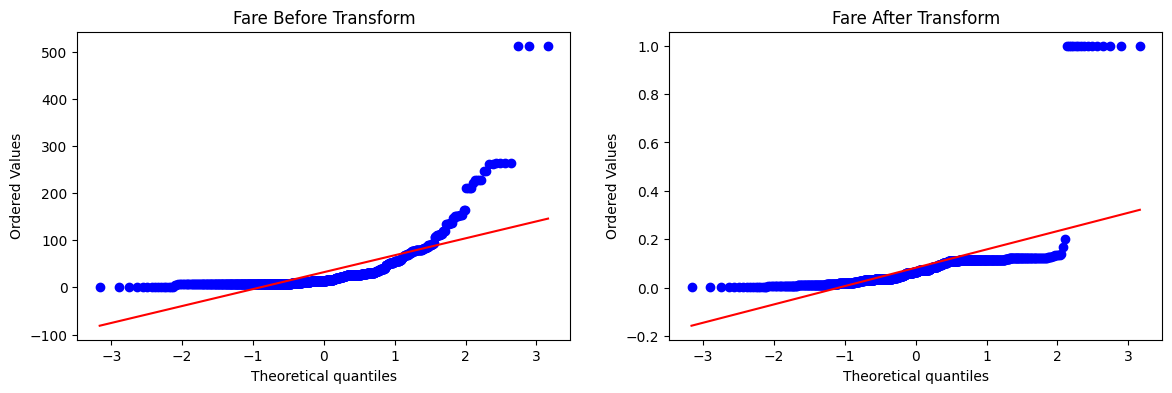

In [39]:
apply_transform(lambda x : 1/(x+1))

Accuracy 0.6195131086142323


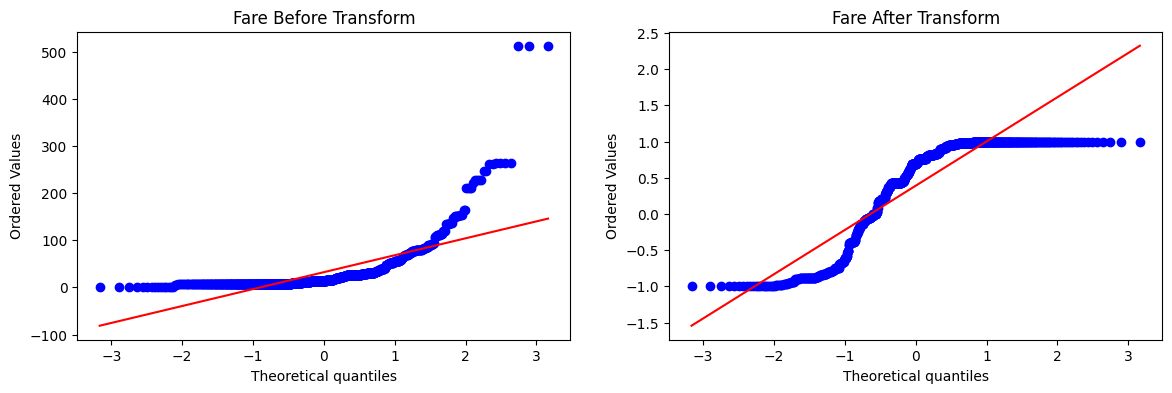

In [42]:
apply_transform(np.sin) 

Accuracy 0.6184144818976279


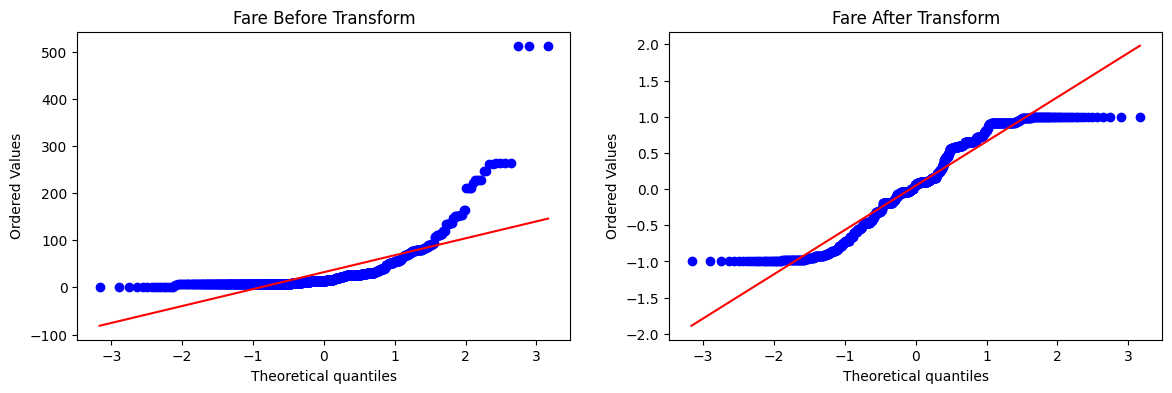

In [43]:
apply_transform(np.cos)                         

Accuracy 0.616167290886392


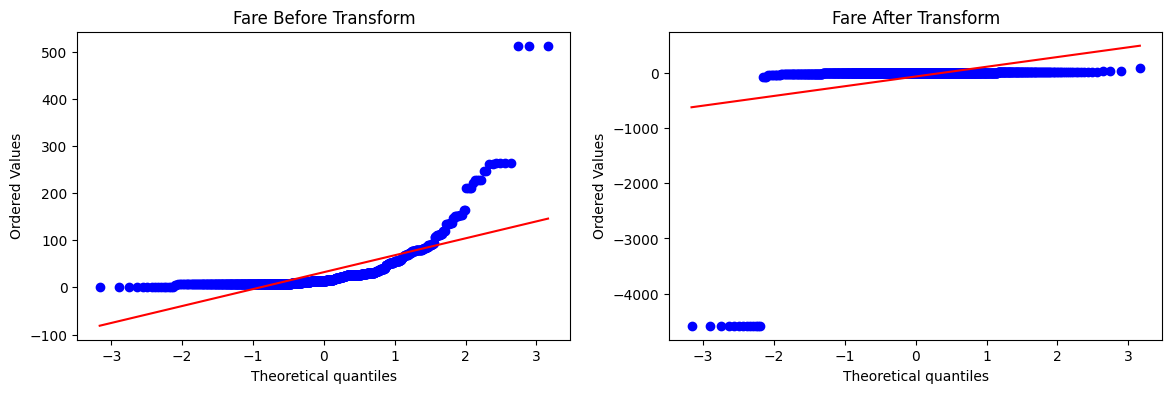

In [41]:
apply_transform(np.tan)

Accuracy 0.6431335830212235


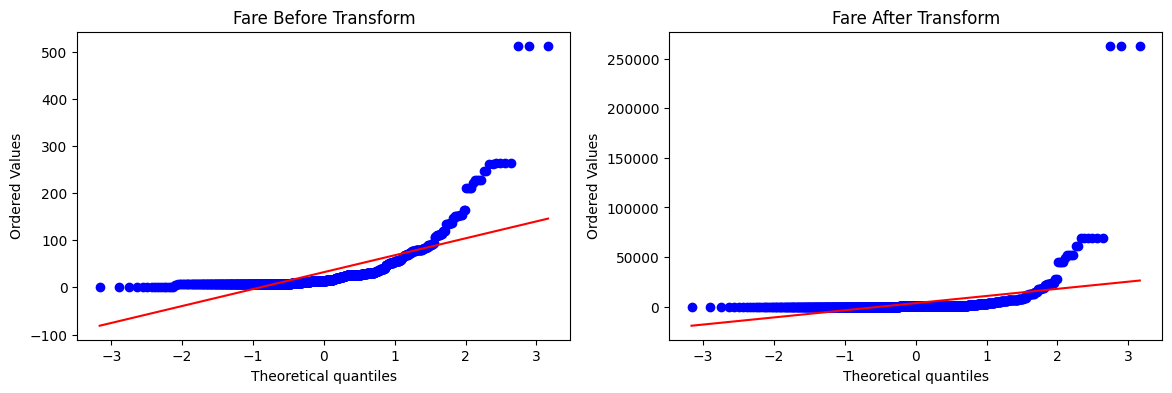

In [44]:
apply_transform(lambda x : x**2 + x)

Accuracy 0.6262796504369538


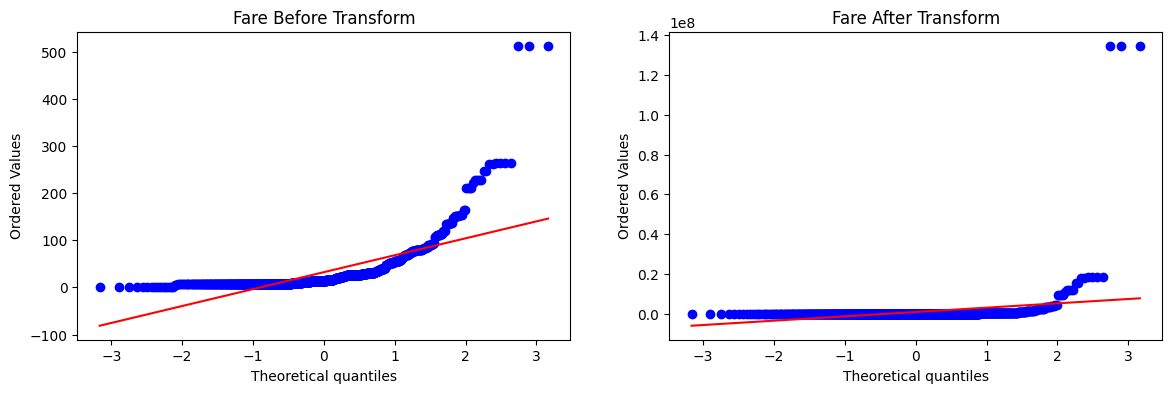

In [45]:
apply_transform(lambda x : x**3 + x**2 + x + 1) 